PENGELOMPOKKAN PEFORMA AKADEMIK SISWA BERDASARKAN NILAI MATEMATIKA, MEMBACA, DAN MENULIS

IMPORT LIBRARY

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score

Tahap 1 Data Understanding

In [132]:
df = pd.read_csv("data_performa_siswa.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1051 entries, 0 to 1050
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Gender                       1051 non-null   object
 1   parental level of education  1051 non-null   object
 2   lunch                        1051 non-null   object
 3   test preparation course      1051 non-null   object
 4   math score                   1051 non-null   int64 
 5   reading score                1051 non-null   int64 
 6   writing score                1051 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 57.6+ KB


,math score,reading score,writing score
count,1051.000000,1051.000000,1051.000000
mean,66.805899,70.143673,69.019981
std,15.272646,15.003470,15.541912
min,0.000000,17.000000,10.000000
25%,57.000000,60.000000,58.000000
50%,67.000000,71.000000,70.000000
75%,78.000000,81.000000,80.000000
max,100.000000,100.000000,100.000000


Tahap 2 Data Preprocessing

In [133]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


,0
Gender,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [134]:
features_score = ['math score', 'reading score', 'writing score']

print("\n--- Penanganan Outlier (Tanpa Menghapus Data) ---")

for col in features_score:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung jumlah outlier
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"Outlier pada {col}: {outliers_count} nilai akan disesuaikan")

print(f"\nTotal data setelah preprocessing: {df.shape[0]} baris ")


--- Penanganan Outlier (Tanpa Menghapus Data) ---
Outlier pada math score: 7 nilai akan disesuaikan
Outlier pada reading score: 6 nilai akan disesuaikan
Outlier pada writing score: 5 nilai akan disesuaikan

Total data setelah preprocessing: 1051 baris 


In [135]:
# --- 2.3 Encoding Data Kategorikal (Label Encoding) ---
# Teknik ini mengubah teks menjadi angka tanpa menambah kolom baru
le = LabelEncoder()
categorical_cols = ['Gender', 'parental level of education', 'lunch', 'test preparation course']

# Kita timpa kolom asli dengan versi angka
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("--- Hasil Encoding ---")
display(df.head())

--- Hasil Encoding ---


,Gender,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,2,1,1,75,90,85
1,1,1,1,1,70,85,80
2,0,1,1,1,85,85,85
3,0,2,1,1,79,90,90
4,0,1,1,1,85,100,100


In [136]:
# --- 2.4 Standarisasi Data ---
# Kita siapkan data untuk model clustering (hanya kolom skor)
features_score = ['math score', 'reading score', 'writing score']
scaler = StandardScaler()

# Melakukan scaling
scaled_values = scaler.fit_transform(df[features_score])

# Membuat dataframe hasil scaling untuk digunakan di tahap berikutnya
df_final_scaled = pd.DataFrame(scaled_values, columns=features_score)

print("\n--- Data Setelah Standarisasi (Siap untuk Model) ---")
display(df_final_scaled.head())


--- Data Setelah Standarisasi (Siap untuk Model) ---


,math score,reading score,writing score
0,0.536777,1.324079,1.028678
1,0.209238,0.990664,0.706814
2,1.191854,0.990664,1.028678
3,0.798808,1.324079,1.350542
4,1.191854,1.990909,1.994270


Tahap 3 Exploratory Data AnalysisEDA

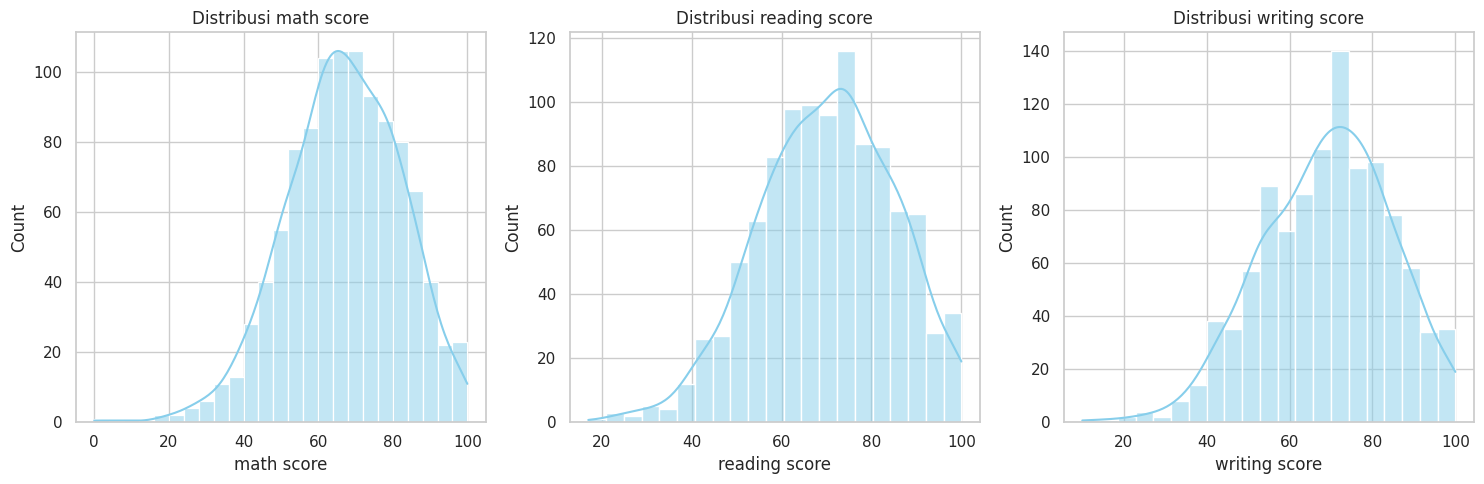

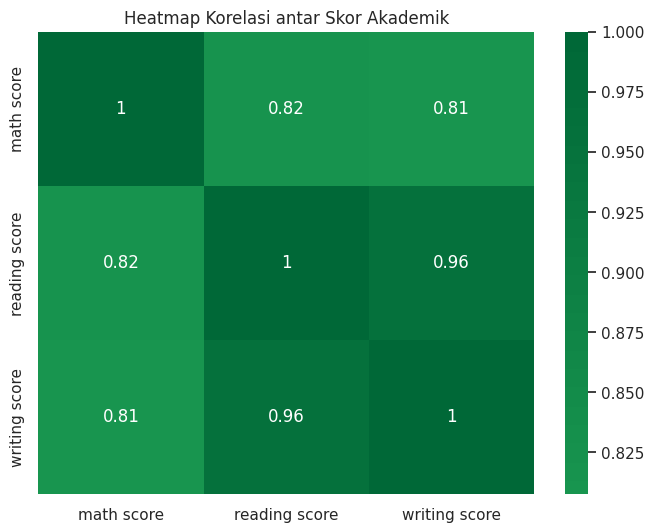

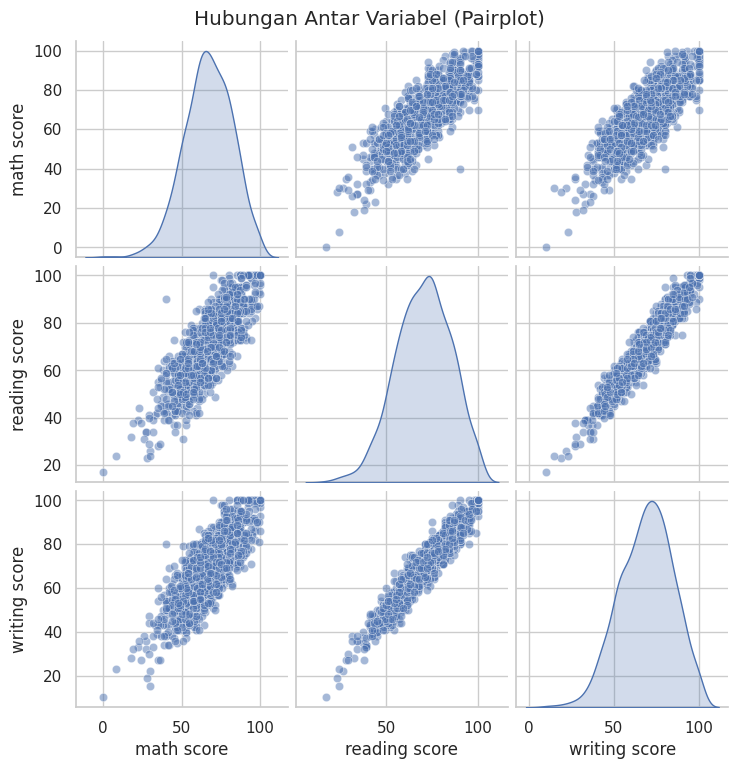

In [137]:
# Mengatur tema visualisasi
sns.set(style="whitegrid")

# --- 3.1 Visualisasi Distribusi Skor (Setelah Cleaning) ---
plt.figure(figsize=(15, 5))
features = ['math score', 'reading score', 'writing score']

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

# --- 3.2 Analisis Korelasi (Heatmap) ---
# Ini penting untuk melihat apakah nilai math, reading, dan writing saling berhubungan
plt.figure(figsize=(8, 6))
corr_matrix = df[features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Heatmap Korelasi antar Skor Akademik')
plt.show()

# --- 3.3 Pairplot (Melihat Sebaran Data untuk Clustering) ---
# Grafik ini menunjukkan bagaimana data "berkumpul" jika dilihat dari dua sudut pandang
sns.pairplot(df[features], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Hubungan Antar Variabel (Pairplot)', y=1.02)
plt.show()

Tahap 4 Data Splitting

In [138]:
# Data
X = df_final_scaled

# Variasi split
X_train_70, X_test_30 = train_test_split(X, test_size=0.30, random_state=42)
X_train_80, X_test_20 = train_test_split(X, test_size=0.20, random_state=42)
X_train_90, X_test_10 = train_test_split(X, test_size=0.10, random_state=42)

print("--- Hasil Data Splitting ---")
print(f"70:30 -> Train: {len(X_train_70)}, Test: {len(X_test_30)}")
print(f"80:20 -> Train: {len(X_train_80)}, Test: {len(X_test_20)}")
print(f"90:10 -> Train: {len(X_train_90)}, Test: {len(X_test_10)}")

--- Hasil Data Splitting ---
70:30 -> Train: 735, Test: 316
80:20 -> Train: 840, Test: 211
90:10 -> Train: 945, Test: 106


Tahap 5 model building

In [139]:
# =========================
# SPLIT 70:30
# =========================

# K-Means
kmeans_70 = KMeans(n_clusters=3, random_state=42)
labels_kmeans_70 = kmeans_70.fit_predict(X_train_70)

# Agglomerative
agglo_70 = AgglomerativeClustering(n_clusters=3)
labels_agglo_70 = agglo_70.fit_predict(X_train_70)

# GMM
gmm_70 = GaussianMixture(n_components=3, random_state=42)
labels_gmm_70 = gmm_70.fit_predict(X_train_70)


# =========================
# SPLIT 80:20
# =========================

kmeans_80 = KMeans(n_clusters=3, random_state=42)
labels_kmeans_80 = kmeans_80.fit_predict(X_train_80)

agglo_80 = AgglomerativeClustering(n_clusters=3)
labels_agglo_80 = agglo_80.fit_predict(X_train_80)

gmm_80 = GaussianMixture(n_components=3, random_state=42)
labels_gmm_80 = gmm_80.fit_predict(X_train_80)


# =========================
# SPLIT 90:10
# =========================

kmeans_90 = KMeans(n_clusters=3, random_state=42)
labels_kmeans_90 = kmeans_90.fit_predict(X_train_90)

agglo_90 = AgglomerativeClustering(n_clusters=3)
labels_agglo_90 = agglo_90.fit_predict(X_train_90)

gmm_90 = GaussianMixture(n_components=3, random_state=42)
labels_gmm_90 = gmm_90.fit_predict(X_train_90)


tahap 6 hyperparameter tuning

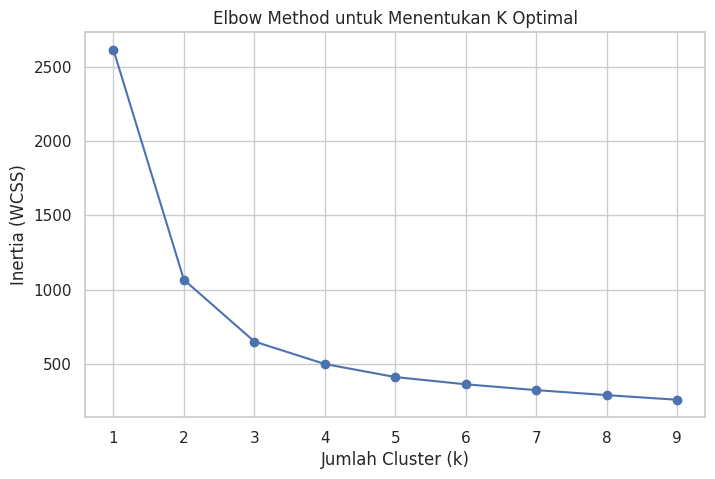

In [140]:
# Skenario pembagian data yang dipilih (misal 80:20)
data_elbow = X_train_80
inertia_values = []
k_range = range(1, 10) # Rentang k diperluas agar siku terlihat

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_elbow)
    inertia_values.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.show()

In [141]:
# Daftar dataset yang akan diuji
datasets = {
    "Split 70:30": X_train_70,
    "Split 80:20": X_train_80,
    "Split 90:10": X_train_90
}

# Daftar nilai k dari 2 sampai 4
k_values = [2, 3, 4]

print("=== TAHAP HYPERPARAMETER TUNING (Analisis Nilai K) ===")

for ds_name, data in datasets.items():
    print(f"\n" + "="*33)
    print(f" DATASET: {ds_name}")
    print("="*33)

    for k in k_values:
        print(f"\n[ Uji Jumlah Cluster k = {k} ]")

        # 1. K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_km = kmeans.fit_predict(data)
        dbi_km = davies_bouldin_score(data, labels_km)

        # 2. Agglomerative (linkage ward)
        agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels_agglo = agglo.fit_predict(data)
        dbi_agglo = davies_bouldin_score(data, labels_agglo)

        # 3. GMM (spherical)
        gmm = GaussianMixture(n_components=k, covariance_type='spherical', random_state=42)
        labels_gmm = gmm.fit_predict(data)
        dbi_gmm = davies_bouldin_score(data, labels_gmm)

        # Tampilkan Hasil Per k
        print(f"  > K-Means       : DBI = {dbi_km:.4f}")
        print(f"  > Agglomerative : DBI = {dbi_agglo:.4f}")
        print(f"  > GMM           : DBI = {dbi_gmm:.4f}")


=== TAHAP HYPERPARAMETER TUNING (Analisis Nilai K) ===

 DATASET: Split 70:30

[ Uji Jumlah Cluster k = 2 ]
  > K-Means       : DBI = 0.7319
  > Agglomerative : DBI = 0.7388
  > GMM           : DBI = 0.7328

[ Uji Jumlah Cluster k = 3 ]
  > K-Means       : DBI = 0.7674
  > Agglomerative : DBI = 0.8594
  > GMM           : DBI = 0.7745

[ Uji Jumlah Cluster k = 4 ]
  > K-Means       : DBI = 0.8075
  > Agglomerative : DBI = 0.8810
  > GMM           : DBI = 0.7946

 DATASET: Split 80:20

[ Uji Jumlah Cluster k = 2 ]
  > K-Means       : DBI = 0.7289
  > Agglomerative : DBI = 0.7130
  > GMM           : DBI = 0.7304

[ Uji Jumlah Cluster k = 3 ]
  > K-Means       : DBI = 0.7602
  > Agglomerative : DBI = 0.8054
  > GMM           : DBI = 0.7657

[ Uji Jumlah Cluster k = 4 ]
  > K-Means       : DBI = 0.8152
  > Agglomerative : DBI = 0.8266
  > GMM           : DBI = 0.7944

 DATASET: Split 90:10

[ Uji Jumlah Cluster k = 2 ]
  > K-Means       : DBI = 0.7255
  > Agglomerative : DBI = 0.7045
  > GM

Tahap 7 evaluasi

In [142]:
results = []

print("=== Model Final (Split 70:30) ===")

# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # Added n_init
labels_kmeans_70 = kmeans.fit_predict(X_train_70)
dbi_kmeans_70 = davies_bouldin_score(X_train_70, labels_kmeans_70)

# Agglomerative (k=2, ward)
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo_70 = agglo.fit_predict(X_train_70)
dbi_agglo_70 = davies_bouldin_score(X_train_70, labels_agglo_70)

# GMM (k=2, spherical)
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
labels_gmm_70 = gmm.fit_predict(X_train_70)
dbi_gmm_70 = davies_bouldin_score(X_train_70, labels_gmm_70)

# Output and store results
print(f"K-Means        :k={gmm.n_components} : DBI = {dbi_kmeans_70:.4f}")
print(f"Agglomerative  :k={gmm.n_components} : DBI = {dbi_agglo_70:.4f}")
print(f"GMM            :k={gmm.n_components} : DBI = {dbi_gmm_70:.4f}")
results.append(("70:30", None, dbi_kmeans_70, None, dbi_agglo_70, None, dbi_gmm_70))

print("\n=== Model Final (Split 80:20) ===")

# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # Added n_init
labels_kmeans_80 = kmeans.fit_predict(X_train_80)
dbi_kmeans_80 = davies_bouldin_score(X_train_80, labels_kmeans_80)

# Agglomerative (k=2, ward)
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo_80 = agglo.fit_predict(X_train_80)
dbi_agglo_80 = davies_bouldin_score(X_train_80, labels_agglo_80)

# GMM (k=2, spherical)
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
labels_gmm_80 = gmm.fit_predict(X_train_80)
dbi_gmm_80 = davies_bouldin_score(X_train_80, labels_gmm_80)

# Output and store results
print(f"K-Means        :k={gmm.n_components} : DBI = {dbi_kmeans_80:.4f}")
print(f"Agglomerative  :k={gmm.n_components} : DBI = {dbi_agglo_80:.4f}")
print(f"GMM            :k={gmm.n_components} : DBI = {dbi_gmm_80:.4f}")
results.append(("80:20", None, dbi_kmeans_80, None, dbi_agglo_80, None, dbi_gmm_80))

print("\n=== Model Final (Split 90:10) ===")

# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10) # Added n_init
labels_kmeans_90 = kmeans.fit_predict(X_train_90)
dbi_kmeans_90 = davies_bouldin_score(X_train_90, labels_kmeans_90)

# Agglomerative (k=2, ward)
agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agglo_90 = agglo.fit_predict(X_train_90)
dbi_agglo_90 = davies_bouldin_score(X_train_90, labels_agglo_90)

# GMM (k=2, spherical)
gmm = GaussianMixture(n_components=2, covariance_type='spherical', random_state=42)
labels_gmm_90 = gmm.fit_predict(X_train_90)
dbi_gmm_90 = davies_bouldin_score(X_train_90, labels_gmm_90)

# Output and store results
print(f"K-Means        :k={gmm.n_components} : DBI = {dbi_kmeans_90:.4f}")
print(f"Agglomerative  :k={gmm.n_components} : DBI = {dbi_agglo_90:.4f}")
print(f"GMM            :k={gmm.n_components} : DBI = {dbi_gmm_90:.4f}")
results.append(("90:10", None, dbi_kmeans_90, None, dbi_agglo_90, None, dbi_gmm_90))

=== Model Final (Split 70:30) ===
K-Means        :k=2 : DBI = 0.7319
Agglomerative  :k=2 : DBI = 0.7388
GMM            :k=2 : DBI = 0.7328

=== Model Final (Split 80:20) ===
K-Means        :k=2 : DBI = 0.7289
Agglomerative  :k=2 : DBI = 0.7130
GMM            :k=2 : DBI = 0.7304

=== Model Final (Split 90:10) ===
K-Means        :k=2 : DBI = 0.7255
Agglomerative  :k=2 : DBI = 0.7045
GMM            :k=2 : DBI = 0.7264


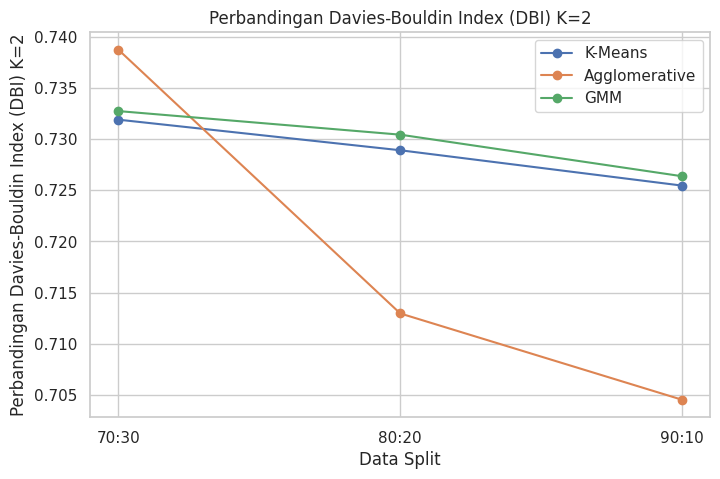

In [143]:
# Reconstruct df_result with DBI columns, assuming 'results' variable is available from Lhu7wmW6hvXR
data = {
    "Split": [r[0] for r in results],
    "K-Means_Silhouette": [r[1] for r in results],
    "K-Means_DBI": [r[2] for r in results],
    "Agglomerative_Silhouette": [r[3] for r in results],
    "Agglomerative_DBI": [r[4] for r in results],
    "GMM_Silhouette": [r[5] for r in results],
    "GMM_DBI": [r[6] for r in results]
}
df_result = pd.DataFrame(data)

plt.figure(figsize=(8,5))

# Plot DBI tiap model
plt.plot(df_result["Split"], df_result["K-Means_DBI"], marker='o', label="K-Means")
plt.plot(df_result["Split"], df_result["Agglomerative_DBI"], marker='o', label="Agglomerative")
plt.plot(df_result["Split"], df_result["GMM_DBI"], marker='o', label="GMM")

# Judul & label
plt.title("Perbandingan Davies-Bouldin Index (DBI) K=2")
plt.xlabel("Data Split")
plt.ylabel("Perbandingan Davies-Bouldin Index (DBI) K=2")

# Tambahan biar rapi
plt.legend()
plt.grid(True)

plt.show()

In [162]:
# --- FUNGSI STANDARISASI LABEL (ML ENGINEER PROTOCOL) ---
def standarize_labels(labels, data_df):
    """
    Memastikan Cluster 0 adalah cluster dengan rata-rata nilai tertinggi.
    """
    # Hitung rata-rata math score untuk cluster 0
    mean_c0 = data_df[labels == 0]['math score'].mean()
    # Hitung rata-rata math score untuk cluster 1
    mean_c1 = data_df[labels == 1]['math score'].mean()

    # Jika Cluster 0 ternyata lebih rendah dari Cluster 1, maka TUKAR
    if mean_c0 < mean_c1:
        return np.where(labels == 0, 1, 0), True
    return labels, False

print("=== PROSES PENYELARASAN LABEL OTOMATIS ===")

# 1. Penyelarasan K-Means
kmeans_labels = kmeans_final.labels_
kmeans_final.labels_, swapped_km = standarize_labels(kmeans_labels, df)
if swapped_km:
    # Jika label ditukar, kita juga wajib menukar urutan cluster_centers_
    # agar fungsi .predict() di Streamlit nanti tidak terbalik
    kmeans_final.cluster_centers_ = kmeans_final.cluster_centers_[::-1]
    print("[v] K-Means diselaraskan (Label Ditukar)")
else:
    print("[v] K-Means sudah sesuai (Tidak Ditukar)")

# 2. Penyelarasan GMM
# GMM tidak punya atribut .labels_, jadi kita ambil dari hasil predict
gmm_initial_labels = gmm_final.predict(df_final_scaled)
gmm_final_labels, swapped_gmm = standarize_labels(gmm_initial_labels, df)
# Catatan: GMM adalah model probabilistik, untuk "menukar" otaknya secara permanen
# tanpa train ulang cukup sulit, jadi kita simpan mapping-nya untuk nanti.
if swapped_gmm:
    print("[v] GMM diselaraskan (Label Ditukar)")
else:
    print("[v] GMM sudah sesuai (Tidak Ditukar)")

# 3. Penyelarasan Agglomerative
agglo_labels = agglo_final.labels_
agglo_final.labels_, swapped_agglo = standarize_labels(agglo_labels, df)
if swapped_agglo:
    print("[v] Agglomerative diselaraskan (Label Ditukar)")
else:
    print("[v] Agglomerative sudah sesuai (Tidak Ditukar)")

# --- VERIFIKASI AKHIR ---
df['Cluster_KM'] = kmeans_final.labels_
df['Cluster_GMM'] = gmm_final_labels # Menggunakan label yang sudah diproses fungsi
df['Cluster_Agglo'] = agglo_final.labels_

print("\n=== HASIL PROFIL AKHIR (KONSISTEN: 0=TINGGI, 1=RENDAH) ===")
for col in ['Cluster_KM', 'Cluster_GMM', 'Cluster_Agglo']:
    print(f"\nProfil {col}:")
    print(df.groupby(col)[['math score', 'reading score', 'writing score']].mean())

=== PROSES PENYELARASAN LABEL OTOMATIS ===
[v] K-Means sudah sesuai (Tidak Ditukar)
[v] GMM sudah sesuai (Tidak Ditukar)
[v] Agglomerative sudah sesuai (Tidak Ditukar)

=== HASIL PROFIL AKHIR (KONSISTEN: 0=TINGGI, 1=RENDAH) ===

Profil Cluster_KM:
            math score  reading score  writing score
Cluster_KM                                          
0            76.770017      80.669506      79.798978
1            54.200431      56.827586      55.383621

Profil Cluster_GMM:
             math score  reading score  writing score
Cluster_GMM                                          
0             76.144279      80.419569      79.452736
1             54.236607      56.312500      54.977679

Profil Cluster_Agglo:
               math score  reading score  writing score
Cluster_Agglo                                          
0               73.079747      76.321519      75.496203
1               47.816092      51.444444      49.417625


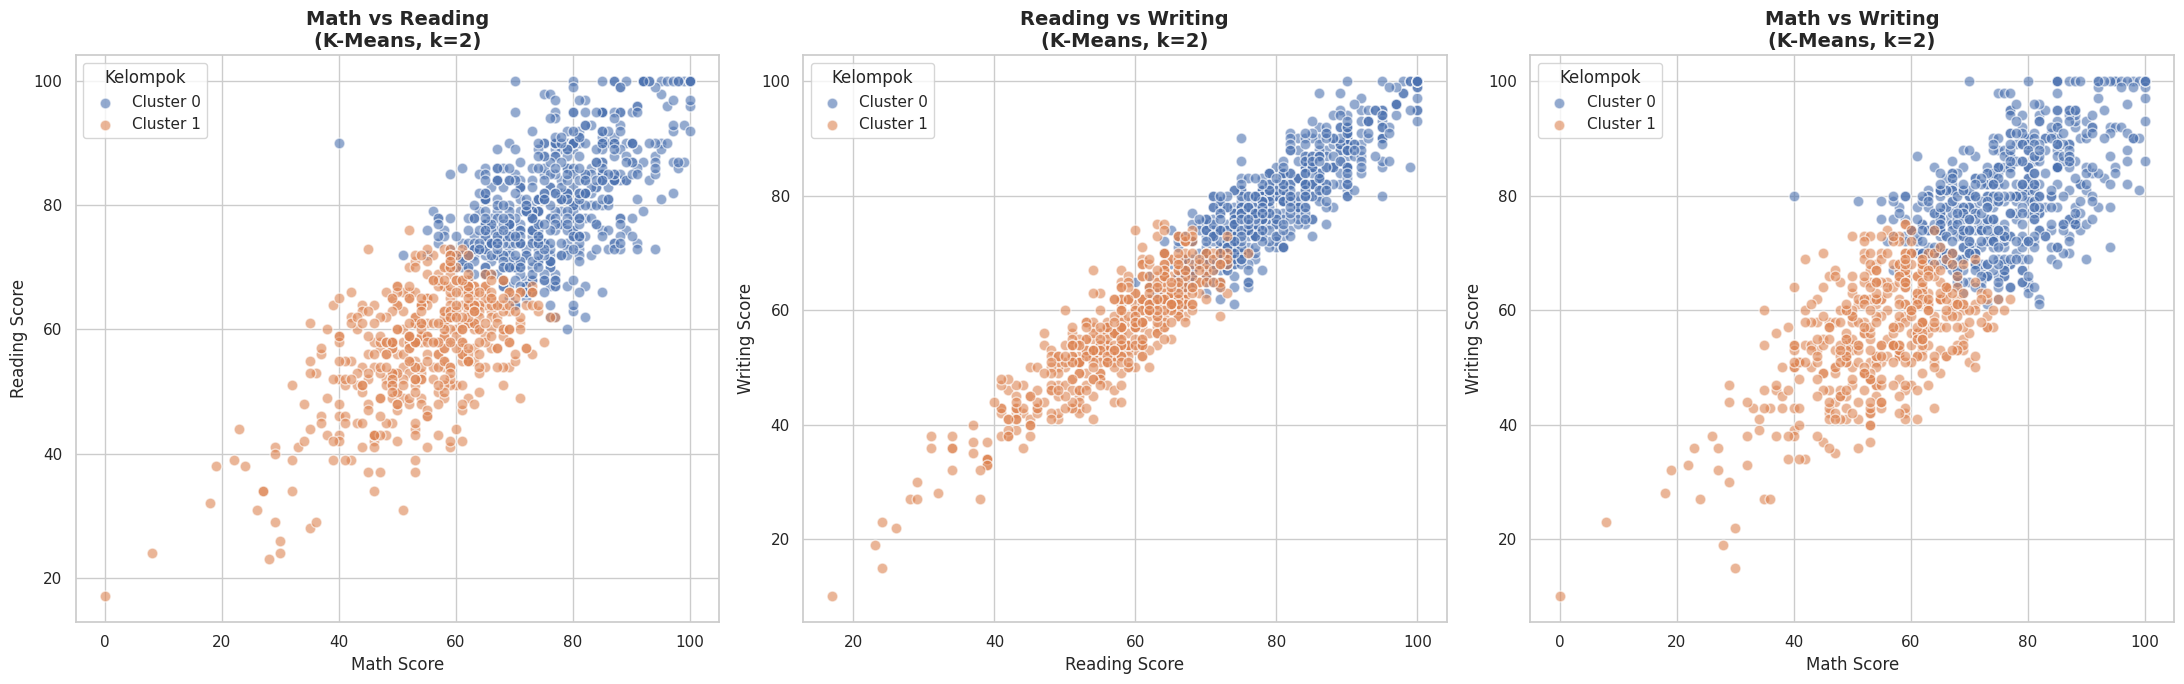

In [145]:
# --- Proses Clustering ---
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
initial_clusters = kmeans_final.fit_predict(df_final_scaled)

# --- Proses Penukaran Label (0 jadi 1, 1 jadi 0) ---
# Menggunakan mapping dictionary untuk menukar identitas cluster
df['Cluster'] = pd.Series(initial_clusters).map({0: 1, 1: 0}).values

# --- 1. Inisialisasi Kanvas Utama (1 Baris, 3 Kolom) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
sns.set_style("whitegrid")

# Konfigurasi data plot agar lebih efisien
plot_targets = [
    {'ax': ax1, 'x': 'math score', 'y': 'reading score', 'title': 'Math vs Reading'},
    {'ax': ax2, 'x': 'reading score', 'y': 'writing score', 'title': 'Reading vs Writing'},
    {'ax': ax3, 'x': 'math score', 'y': 'writing score', 'title': 'Math vs Writing'}
]

# --- 2. Looping untuk Menggambar Ketiga Plot ---
# Warna palette manual agar konsisten setelah ditukar (Opsional)
colors = {0: 'blue', 1: 'orange'}

for target in plot_targets:
    for cluster in sorted(df['Cluster'].unique()):
        subset = df[df['Cluster'] == cluster]
        target['ax'].scatter(
            subset[target['x']],
            subset[target['y']],
            label=f"Cluster {cluster}",
            alpha=0.6,
            edgecolors='w',
            s=60
        )

    target['ax'].set_xlabel(target['x'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_ylabel(target['y'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_title(f"{target['title']}\n(K-Means, k=2)", fontsize=14, fontweight='bold')
    target['ax'].legend(title="Kelompok")

plt.tight_layout()
plt.show()

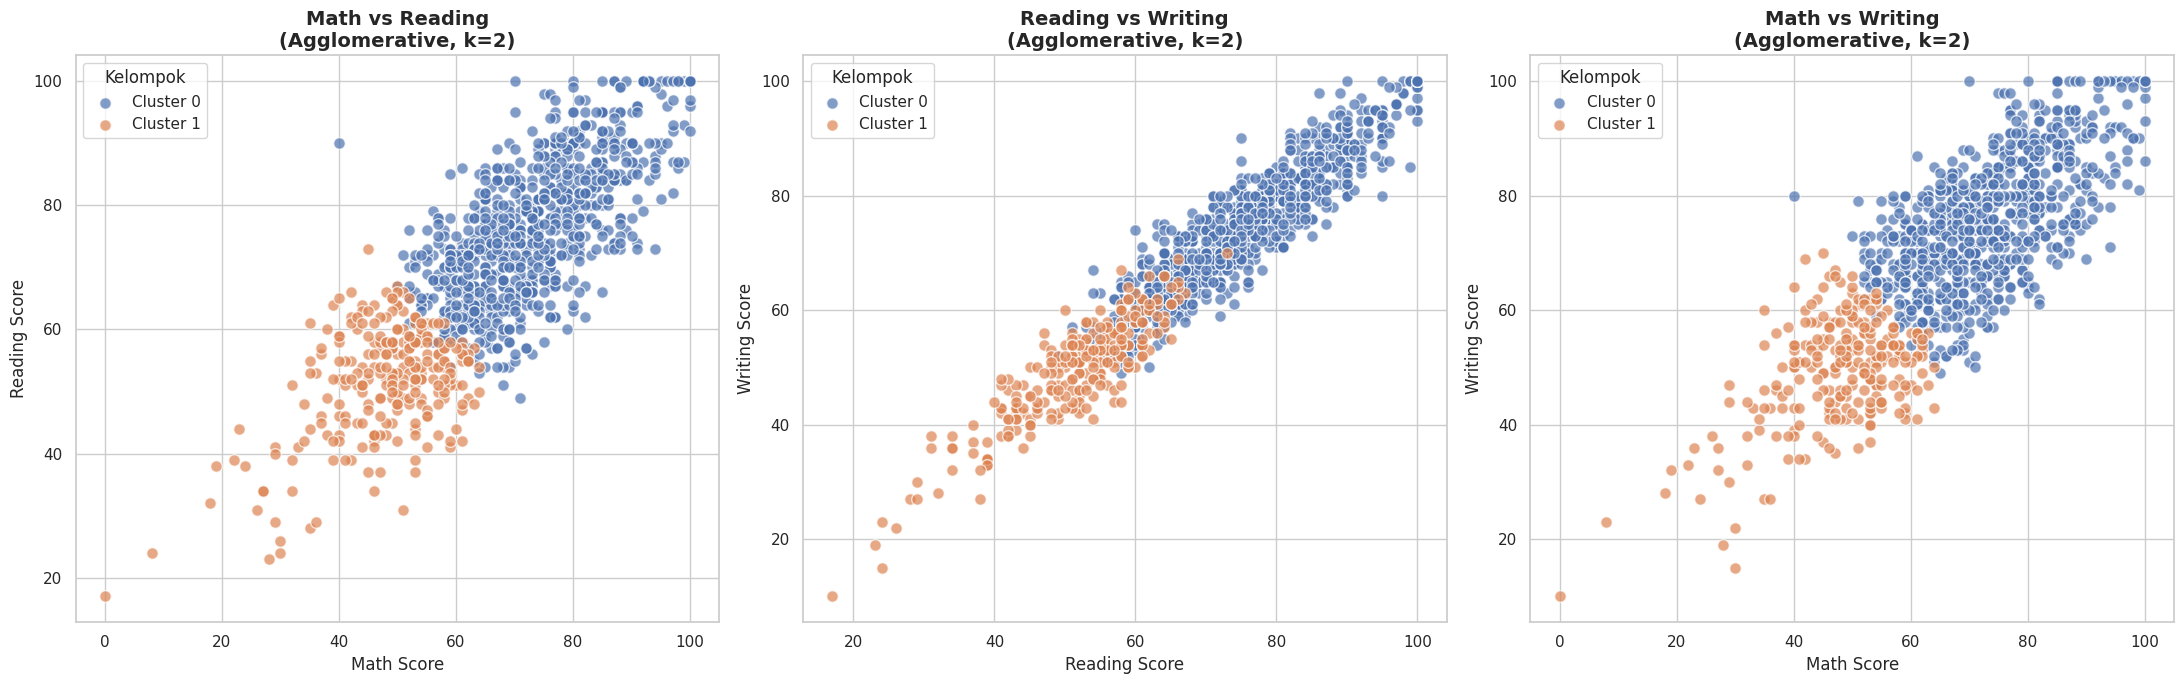

In [146]:
# --- Proses Clustering Menggunakan Model Terbaik ---
# Menggunakan n_clusters=2 dan linkage='ward' sesuai hasil tuning
agglo_final = AgglomerativeClustering(n_clusters=2, linkage='ward')
df['Cluster'] = agglo_final.fit_predict(df_final_scaled)

# --- 1. Inisialisasi Kanvas Utama (1 Baris, 3 Kolom) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
sns.set_style("whitegrid")

# Konfigurasi data plot
plot_targets = [
    {'ax': ax1, 'x': 'math score', 'y': 'reading score', 'title': 'Math vs Reading'},
    {'ax': ax2, 'x': 'reading score', 'y': 'writing score', 'title': 'Reading vs Writing'},
    {'ax': ax3, 'x': 'math score', 'y': 'writing score', 'title': 'Math vs Writing'}
]

# --- 2. Looping untuk Menggambar Ketiga Plot ---
for target in plot_targets:
    # Menggunakan palet warna yang kontras agar mudah dibedakan di PPT
    colors = ['#4C72B0', '#DD8452']
    for i, cluster in enumerate(sorted(df['Cluster'].unique())):
        subset = df[df['Cluster'] == cluster]
        target['ax'].scatter(
            subset[target['x']],
            subset[target['y']],
            label=f"Cluster {cluster}",
            alpha=0.7,
            edgecolors='w',
            s=70,
            c=colors[i]
        )

    # Set Label dan Judul secara dinamis
    target['ax'].set_xlabel(target['x'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_ylabel(target['y'].replace(' score', '').title() + " Score", fontsize=12)
    # Judul diubah menjadi Agglomerative agar sesuai dengan model
    target['ax'].set_title(f"{target['title']}\n(Agglomerative, k=2)", fontsize=14, fontweight='bold')
    target['ax'].legend(title="Kelompok")

# --- Tambahan Akhir agar rapi ---
plt.tight_layout()
plt.show()

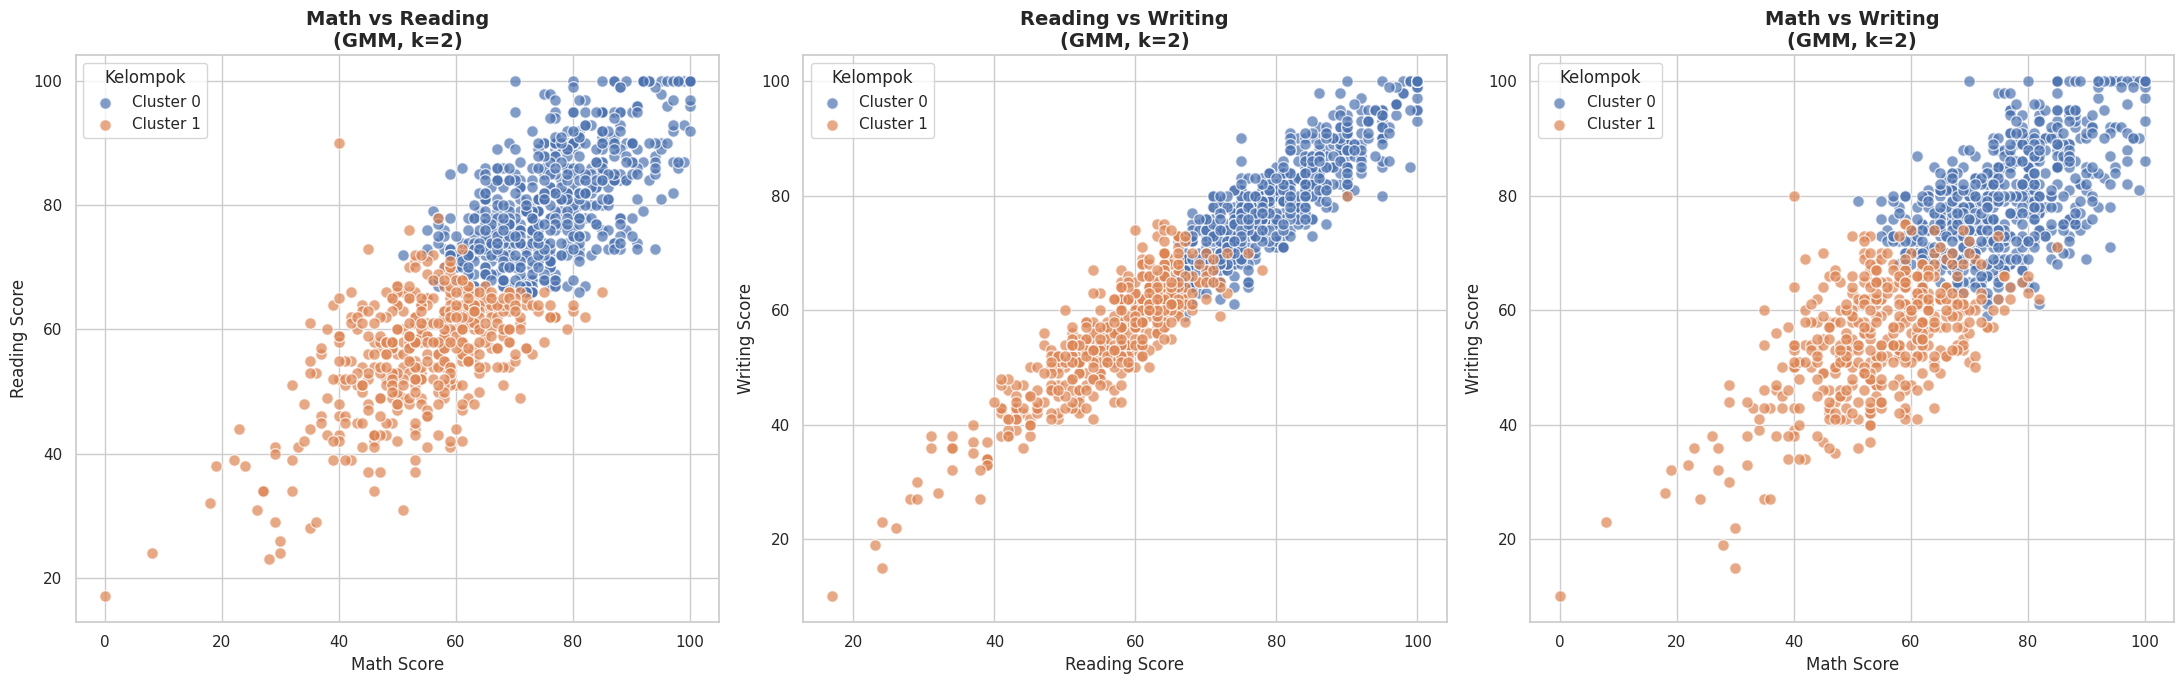

In [147]:
# --- Proses Clustering Menggunakan GMM ---
# Menggunakan n_components=2 (setara dengan n_clusters)
gmm_final = GaussianMixture(n_components=2, random_state=42)
df['Cluster'] = gmm_final.fit_predict(df_final_scaled)

# --- 1. Inisialisasi Kanvas Utama (1 Baris, 3 Kolom) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
sns.set_style("whitegrid")

# Konfigurasi data plot
plot_targets = [
    {'ax': ax1, 'x': 'math score', 'y': 'reading score', 'title': 'Math vs Reading'},
    {'ax': ax2, 'x': 'reading score', 'y': 'writing score', 'title': 'Reading vs Writing'},
    {'ax': ax3, 'x': 'math score', 'y': 'writing score', 'title': 'Math vs Writing'}
]

# --- 2. Looping untuk Menggambar Ketiga Plot ---
for target in plot_targets:
    # Menggunakan palet warna yang konsisten
    colors = ['#4C72B0', '#DD8452']
    for i, cluster in enumerate(sorted(df['Cluster'].unique())):
        subset = df[df['Cluster'] == cluster]
        target['ax'].scatter(
            subset[target['x']],
            subset[target['y']],
            label=f"Cluster {cluster}",
            alpha=0.7,
            edgecolors='w',
            s=70,
            c=colors[i]
        )

    # Set Label dan Judul secara dinamis
    target['ax'].set_xlabel(target['x'].replace(' score', '').title() + " Score", fontsize=12)
    target['ax'].set_ylabel(target['y'].replace(' score', '').title() + " Score", fontsize=12)
    # Judul diubah menjadi GMM
    target['ax'].set_title(f"{target['title']}\n(GMM, k=2)", fontsize=14, fontweight='bold')
    target['ax'].legend(title="Kelompok")

# --- Tambahan Akhir agar rapi ---
plt.tight_layout()
plt.show()

Tahap 8 Deployment

In [148]:
import pickle
import numpy as np

# 1. Hitung centroid untuk Agglomerative Clustering secara manual
# Kita ambil rata-rata fitur yang di-scale berdasarkan label cluster-nya
labels_agglo = agglo_final.labels_
centroids = []
for i in range(2): # Karena kita menggunakan k=2
    centroids.append(df_final_scaled[labels_agglo == i].mean(axis=0))
centroids = np.array(centroids)

# 2. Simpan semua model & scaler
with open('model_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

with open('model_gmm.pkl', 'wb') as f:
    pickle.dump(gmm_final, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Simpan centroid Agglomerative yang baru saja dibuat
with open('agglo_centroids.pkl', 'wb') as f:
    pickle.dump(centroids, f)

print("Semua model (KMeans, GMM), scaler, dan centroid Agglomerative berhasil disimpan!")

Semua model (KMeans, GMM), scaler, dan centroid Agglomerative berhasil disimpan!


In [149]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np
from scipy.spatial.distance import cdist

# Set judul halaman agar terlihat profesional
st.set_page_config(page_title="Student Performance Prediction", page_icon="🎓")

# Memuat aset model dengan caching agar aplikasi cepat
@st.cache_resource
def load_assets():
    try:
        with open('model_kmeans.pkl', 'rb') as f:
            model_km = pickle.load(f)
        with open('model_gmm.pkl', 'rb') as f:
            model_gmm = pickle.load(f)
        with open('scaler.pkl', 'rb') as f:
            sc = pickle.load(f)
        with open('agglo_centroids.pkl', 'rb') as f:
            agglo_centroids = pickle.load(f)
        return model_km, model_gmm, sc, agglo_centroids
    except FileNotFoundError as e:
        st.error(f"Gagal memuat file: {e}. Pastikan semua file .pkl sudah tersedia.")
        return None, None, None, None

kmeans, gmm, scaler, agglo_centroids = load_assets()

# --- UI Header ---
st.title("🎓 Klasifikasi Performa Akademik Siswa")
st.markdown("""
Aplikasi ini mengelompokkan siswa berdasarkan skor akademik menggunakan model yang telah divalidasi.
**Standar Label:**
* **Cluster 0**: Performa Tinggi (High Performance)
* **Cluster 1**: Performa Rendah/Sedang (Lower Performance)
""")

# --- Sidebar Input ---
st.sidebar.header("📝 Input Nilai Siswa")
math_score = st.sidebar.slider("Math Score", 0, 100, 80)
reading_score = st.sidebar.slider("Reading Score", 0, 100, 80)
writing_score = st.sidebar.slider("Writing Score", 0, 100, 80)

algo_choice = st.selectbox(
    "Pilih Algoritma Clustering",
    ["K-Means", "Gaussian Mixture Model (GMM)", "Agglomerative Clustering"]
)

# --- Logika Analisis ---
if st.button("Jalankan Analisis"):
    if scaler is not None:
        # 1. Transformasi Data (Sangat krusial untuk ML)
        data = np.array([[math_score, reading_score, writing_score]])
        data_scaled = scaler.transform(data)
        cluster = None

        # 2. Prediksi berdasarkan model yang dipilih
        if algo_choice == "K-Means":
            cluster = kmeans.predict(data_scaled)[0]

        elif algo_choice == "Gaussian Mixture Model (GMM)":
            cluster = gmm.predict(data_scaled)[0]

        elif algo_choice == "Agglomerative Clustering":
            if agglo_centroids is not None:
                # Menggunakan jarak Euclidean ke centroid hasil profiling
                distances = cdist(data_scaled, agglo_centroids)
                cluster = np.argmin(distances)
            else:
                st.error("Centroid Agglomerative tidak ditemukan.")

        # 3. Output Visual
        if cluster is not None:
            st.divider()
            st.subheader(f"Hasil Prediksi: Cluster {cluster}")

            if cluster == 0:
                st.success("### ✨ Karakteristik: Performa Tinggi")
                st.write(f"Berdasarkan algoritma **{algo_choice}**, siswa ini masuk ke dalam kelompok dengan rata-rata nilai akademik yang superior.")
                st.markdown("- **Kekuatan:** Konsistensi nilai di atas 70.\n- **Rekomendasi:** Berikan materi pengayaan atau akselerasi.")
            else:
                st.warning("### ⚠️ Karakteristik: Performa Rendah/Sedang")
                st.write(f"Berdasarkan algoritma **{algo_choice}**, siswa ini masuk ke dalam kelompok yang memerlukan perhatian lebih.")
                st.markdown("- **Kelemahan:** Nilai cenderung di bawah 60.\n- **Rekomendasi:** Perlu bimbingan belajar tambahan atau mentoring sebaya.")

            # Menampilkan tabel data input untuk verifikasi
            st.table(pd.DataFrame(data, columns=['Math', 'Reading', 'Writing']))
    else:
        st.error("Aplikasi tidak dapat dijalankan karena model belum dimuat.")

Overwriting app.py


In [150]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn

Overwriting requirements.txt


Semua file (`model_kmeans.pkl`, `model_gmm.pkl`, `scaler.pkl`, `app.py`, dan `requirements.txt`) sudah siap. Anda dapat mengunduh file ini dan mengunggahnya ke GitHub untuk dideploy melalui Streamlit Cloud.